---
## 0. Install & Import Libraries

In [1]:
# ── Install (run once if needed) ──────────────────────────────────────────
# !pip install imbalanced-learn xgboost scikit-learn matplotlib seaborn pandas numpy tensorflow

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc, classification_report
)
from imblearn.over_sampling import SMOTE

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

print('Libraries loaded successfully.')
# print(f'TensorFlow version: {tf.__version__}')

Libraries loaded successfully.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
train_raw = pd.read_csv('UNSW_NB15_train_40k.csv')
test_raw  = pd.read_csv('UNSW_NB15_test_10k.csv')

print('Training set shape :', train_raw.shape)
print('Testing  set shape :', test_raw.shape)
print()
print('=== First 5 rows ===')
train_raw.head()

Training set shape : (40000, 16)
Testing  set shape : (10000, 16)

=== First 5 rows ===


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0


In [3]:
# ── Basic info ────────────────────────────────────────────────────────────
print('=== Data Types & Non-Null Counts ===')
train_raw.info()
print()
print('=== Missing Values ===')
print(train_raw.isnull().sum())

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   proto    40000 non-null  str    
 1   state    40000 non-null  str    
 2   service  40000 non-null  str    
 3   dur      40000 non-null  float64
 4   sbytes   40000 non-null  int64  
 5   dbytes   40000 non-null  int64  
 6   spkts    40000 non-null  int64  
 7   dpkts    40000 non-null  int64  
 8   sload    40000 non-null  float64
 9   dload    40000 non-null  float64
 10  sttl     40000 non-null  int64  
 11  dttl     40000 non-null  int64  
 12  smean    40000 non-null  int64  
 13  dmean    40000 non-null  int64  
 14  sinpkt   40000 non-null  float64
 15  label    40000 non-null  int64  
dtypes: float64(4), int64(9), str(3)
memory usage: 4.9 MB

=== Missing Values ===
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts   

In [4]:
# ── Descriptive statistics ────────────────────────────────────────────────
print('=== Descriptive Statistics (Numerical Features) ===')
train_raw.describe().T.style.background_gradient(cmap='Blues')

=== Descriptive Statistics (Numerical Features) ===


,count,mean,std,min,25%,50%,75%,max
dur,40000.000000,1.181550,5.715719,0.000000,0.000010,0.026797,0.647432,59.999989
sbytes,40000.000000,6409.099025,125252.505243,46.000000,146.000000,810.000000,2558.000000,12029826.000000
dbytes,40000.000000,24713.269875,170838.115164,0.000000,0.000000,320.000000,3380.000000,14655550.000000
spkts,40000.000000,26.478525,106.980146,1.000000,2.000000,10.000000,22.000000,9094.000000
dpkts,40000.000000,30.275575,129.778977,0.000000,0.000000,6.000000,22.000000,10974.000000
sload,40000.000000,45729073.105196,175004052.891331,0.000000,12442.756102,517928.312500,4667234.500000,5988000256.000000
dload,40000.000000,1471366.130030,3451494.048965,0.000000,0.000000,15074.691410,687258.687500,22353024.000000
sttl,40000.000000,121.099150,108.934310,0.000000,31.000000,31.000000,254.000000,255.000000
dttl,40000.000000,70.684150,97.926862,0.000000,0.000000,29.000000,29.000000,254.000000
smean,40000.000000,140.207025,198.910097,28.000000,57.000000,73.000000,117.000000,1504.000000


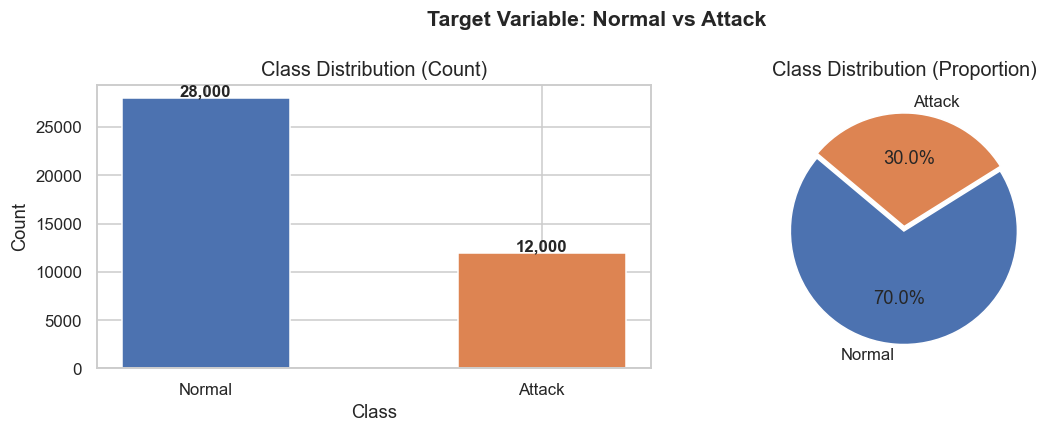

Imbalance ratio (Normal:Attack) = 2.33 :1

Interpretation: The dataset has a 70:30 Normal-to-Attack ratio. Mild imbalance — SMOTE will be applied to ensure the minority class is well represented during training.


In [5]:
# ── 1. Class Distribution ─────────────────────────────────────────────────
label_map  = {0: 'Normal', 1: 'Attack'}
label_cnts = train_raw['label'].map(label_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
bars = axes[0].bar(label_cnts.index, label_cnts.values,
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, val in zip(bars, label_cnts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')

# Pie
axes[1].pie(label_cnts.values, labels=label_cnts.index,
            autopct='%1.1f%%', startangle=140,
            colors=['#4C72B0', '#DD8452'], explode=(0.04, 0))
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.suptitle('Target Variable: Normal vs Attack', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_class_dist.png', bbox_inches='tight')
plt.show()

print('Imbalance ratio (Normal:Attack) =',
      round(label_cnts['Normal'] / label_cnts['Attack'], 2), ':1')
print('\nInterpretation: The dataset has a 70:30 Normal-to-Attack ratio.',
      'Mild imbalance — SMOTE will be applied to ensure the minority class',
      'is well represented during training.')

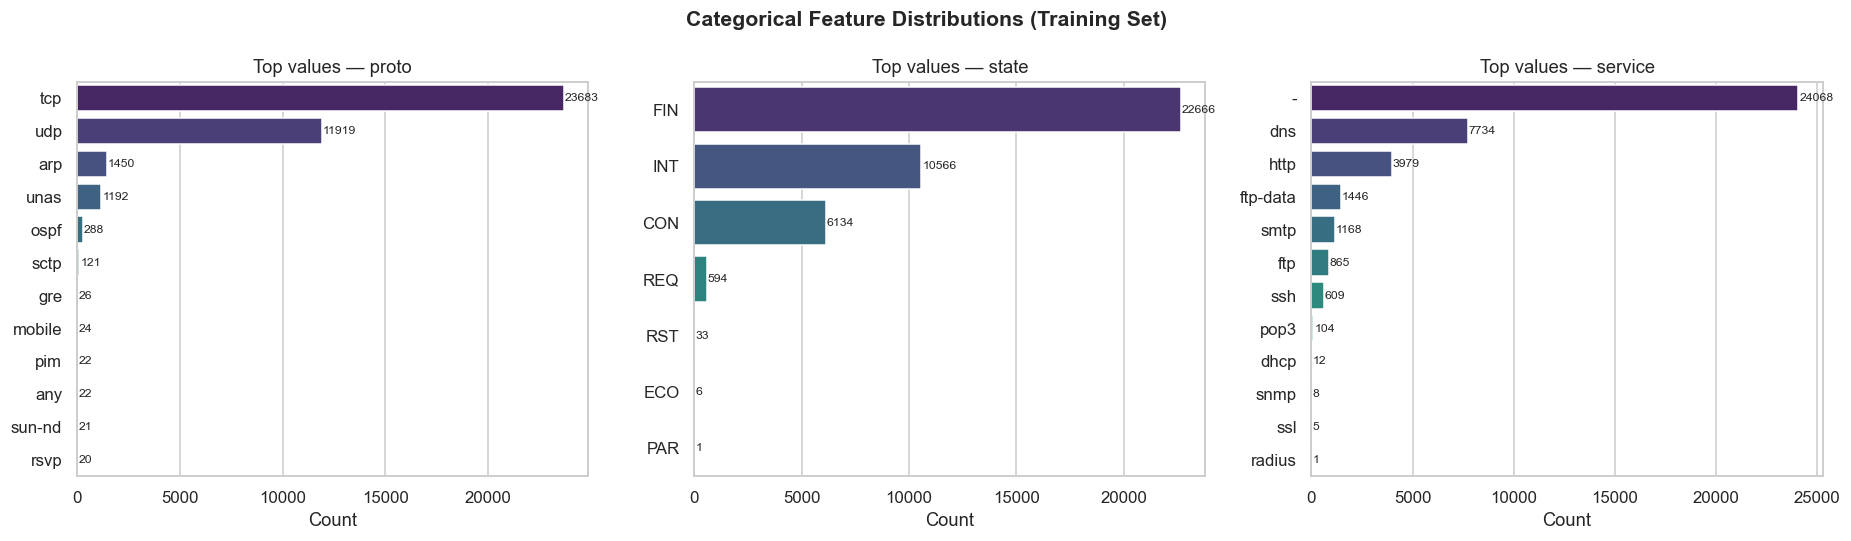

Interpretation:
 proto   — TCP dominates, followed by UDP. High cardinality needs encoding.
 state   — CON and FIN are most frequent, representing established connections.
 service — Most records have "-" (no specific service), HTTP is next.


In [6]:
# ── 2. Categorical Feature Distributions ─────────────────────────────────
cat_cols = ['proto', 'state', 'service']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col in zip(axes, cat_cols):
    top = train_raw[col].value_counts().head(12)
    sns.barplot(x=top.values, y=top.index, ax=ax,
                hue=top.index, palette='viridis', legend=False)
    ax.set_title(f'Top values — {col}', fontsize=12)
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    for i, v in enumerate(top.values):
        ax.text(v + 50, i, str(v), va='center', fontsize=8)

plt.suptitle('Categorical Feature Distributions (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cat_dist.png', bbox_inches='tight')
plt.show()

print('Interpretation:')
print(' proto   — TCP dominates, followed by UDP. High cardinality needs encoding.')
print(' state   — CON and FIN are most frequent, representing established connections.')
print(' service — Most records have "-" (no specific service), HTTP is next.')

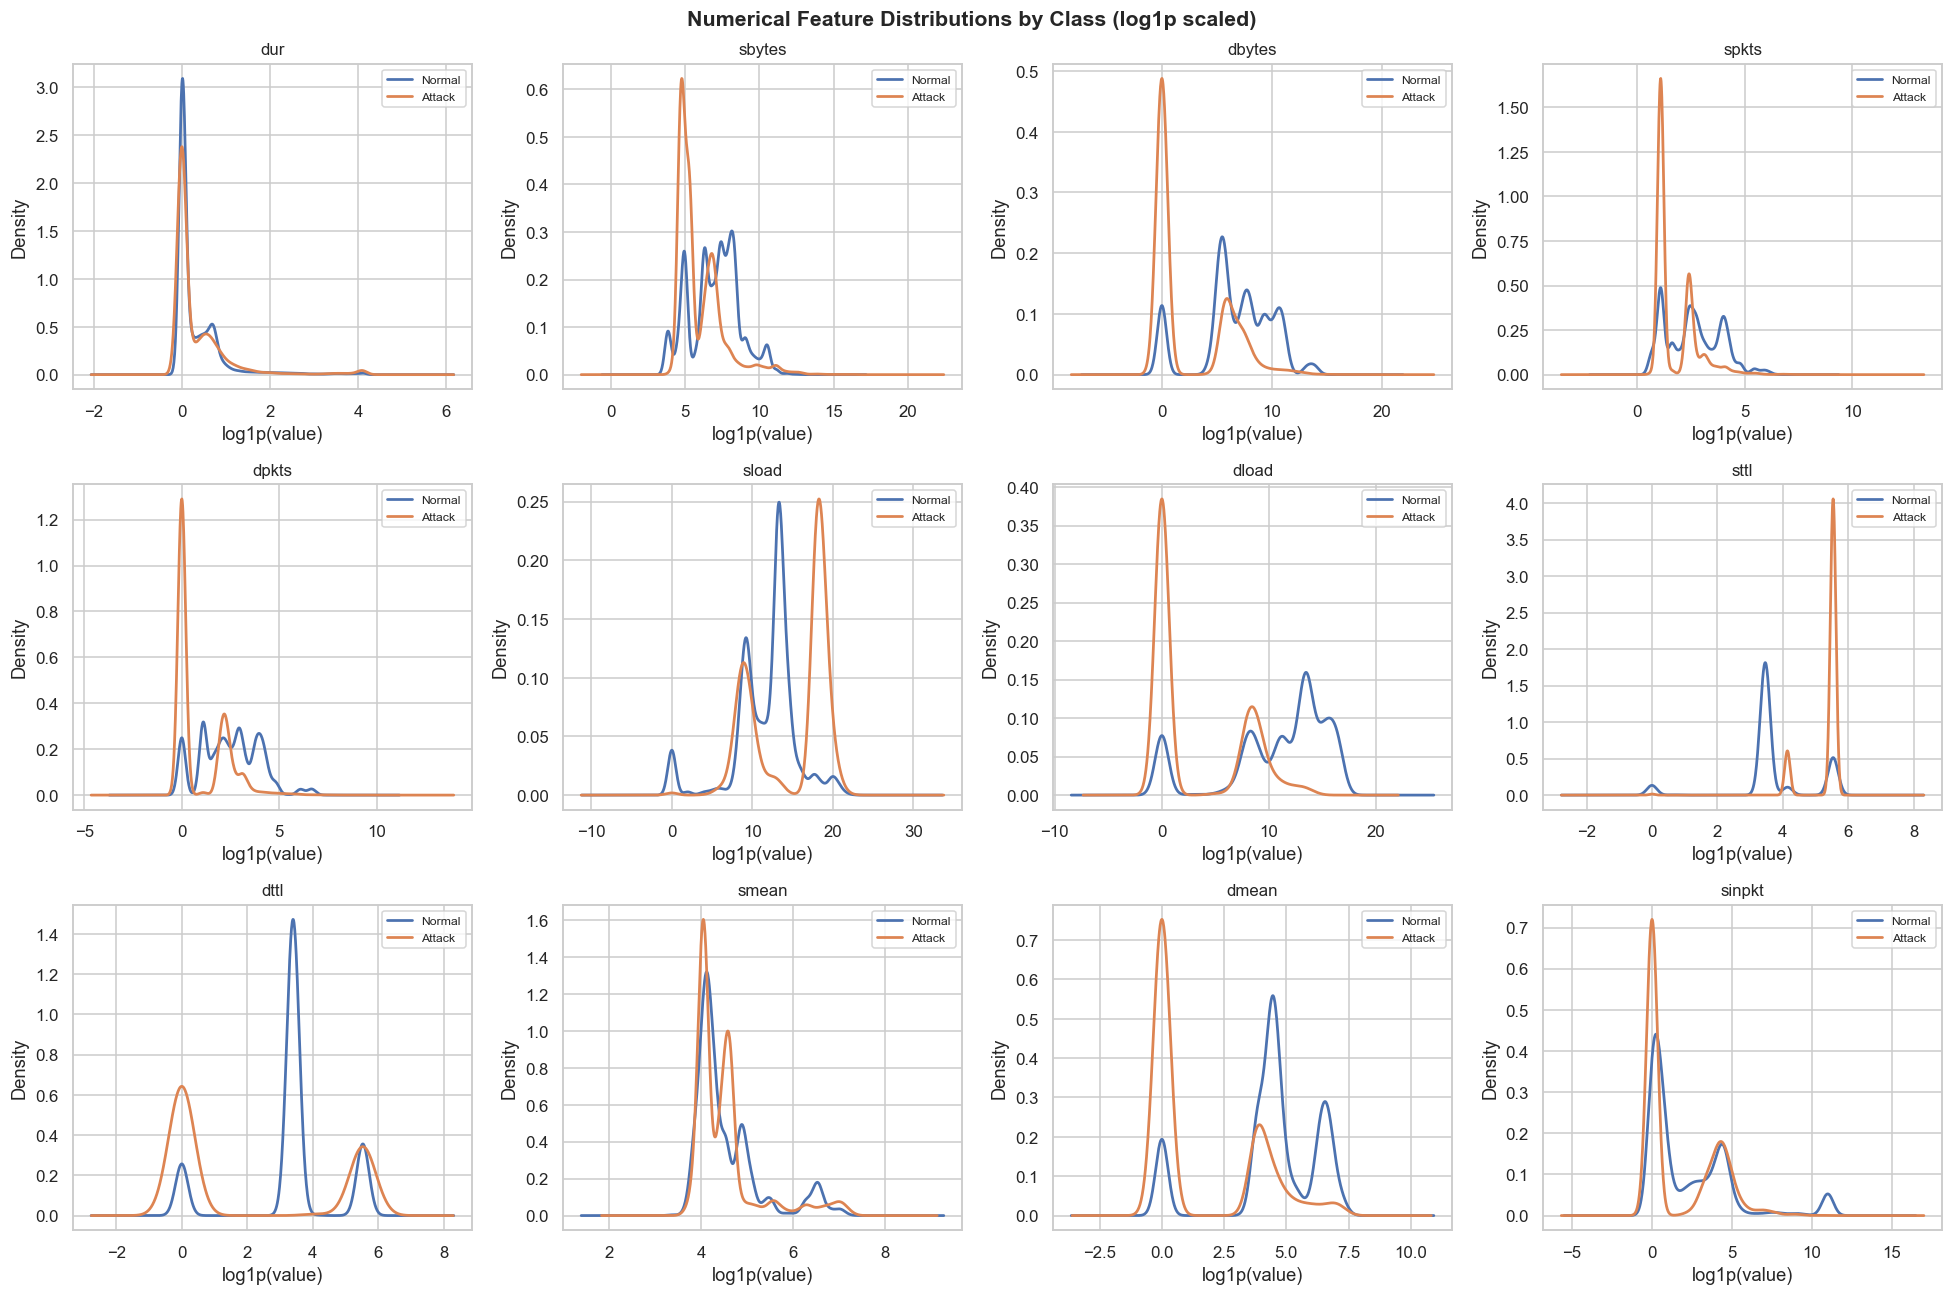

Interpretation: Many features exhibit heavy right skew (sbytes, dbytes, sload, dload).
Class-separated distributions show that sttl, dttl, smean, dpkts are discriminative.


In [7]:
# ── 3. Numerical Feature Distributions ───────────────────────────────────
num_cols = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts',
            'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for lbl, clr in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = train_raw[train_raw['label'] == lbl][col]
        subset = np.log1p(subset.clip(lower=0))
        subset.plot.kde(ax=ax, label=label_map[lbl], color=clr, linewidth=1.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('log1p(value)')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Class (log1p scaled)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_num_dist.png', bbox_inches='tight')
plt.show()

print('Interpretation: Many features exhibit heavy right skew (sbytes, dbytes, sload, dload).')
print('Class-separated distributions show that sttl, dttl, smean, dpkts are discriminative.')

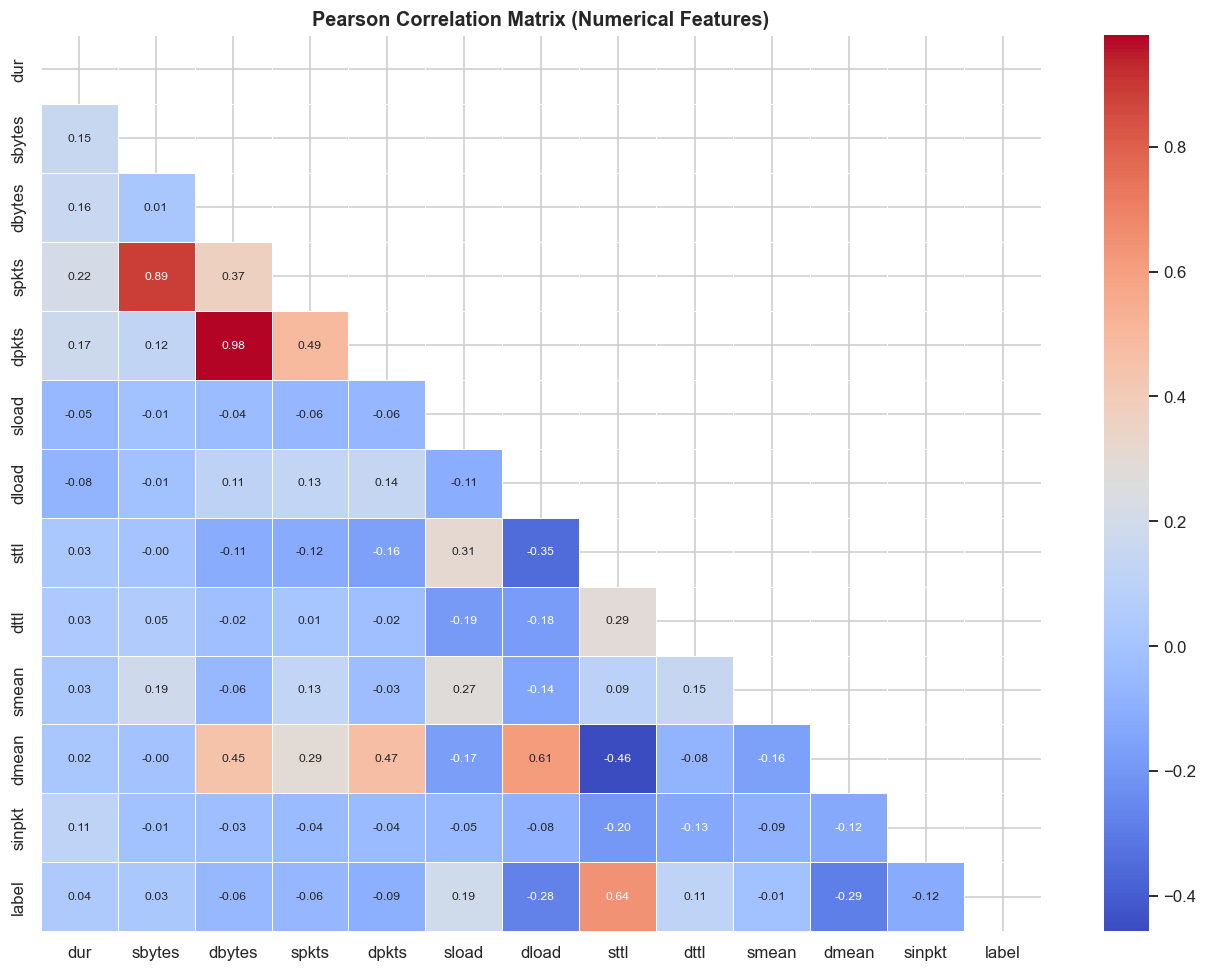

Interpretation: sbytes/sload and dbytes/dload are strongly correlated (multicollinearity).
sttl and dttl show moderate negative correlation with label, making them useful features.


In [8]:
# ── 4. Correlation Heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = train_raw[num_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix (Numerical Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_corr.png', bbox_inches='tight')
plt.show()

print('Interpretation: sbytes/sload and dbytes/dload are strongly correlated (multicollinearity).')
print('sttl and dttl show moderate negative correlation with label, making them useful features.')

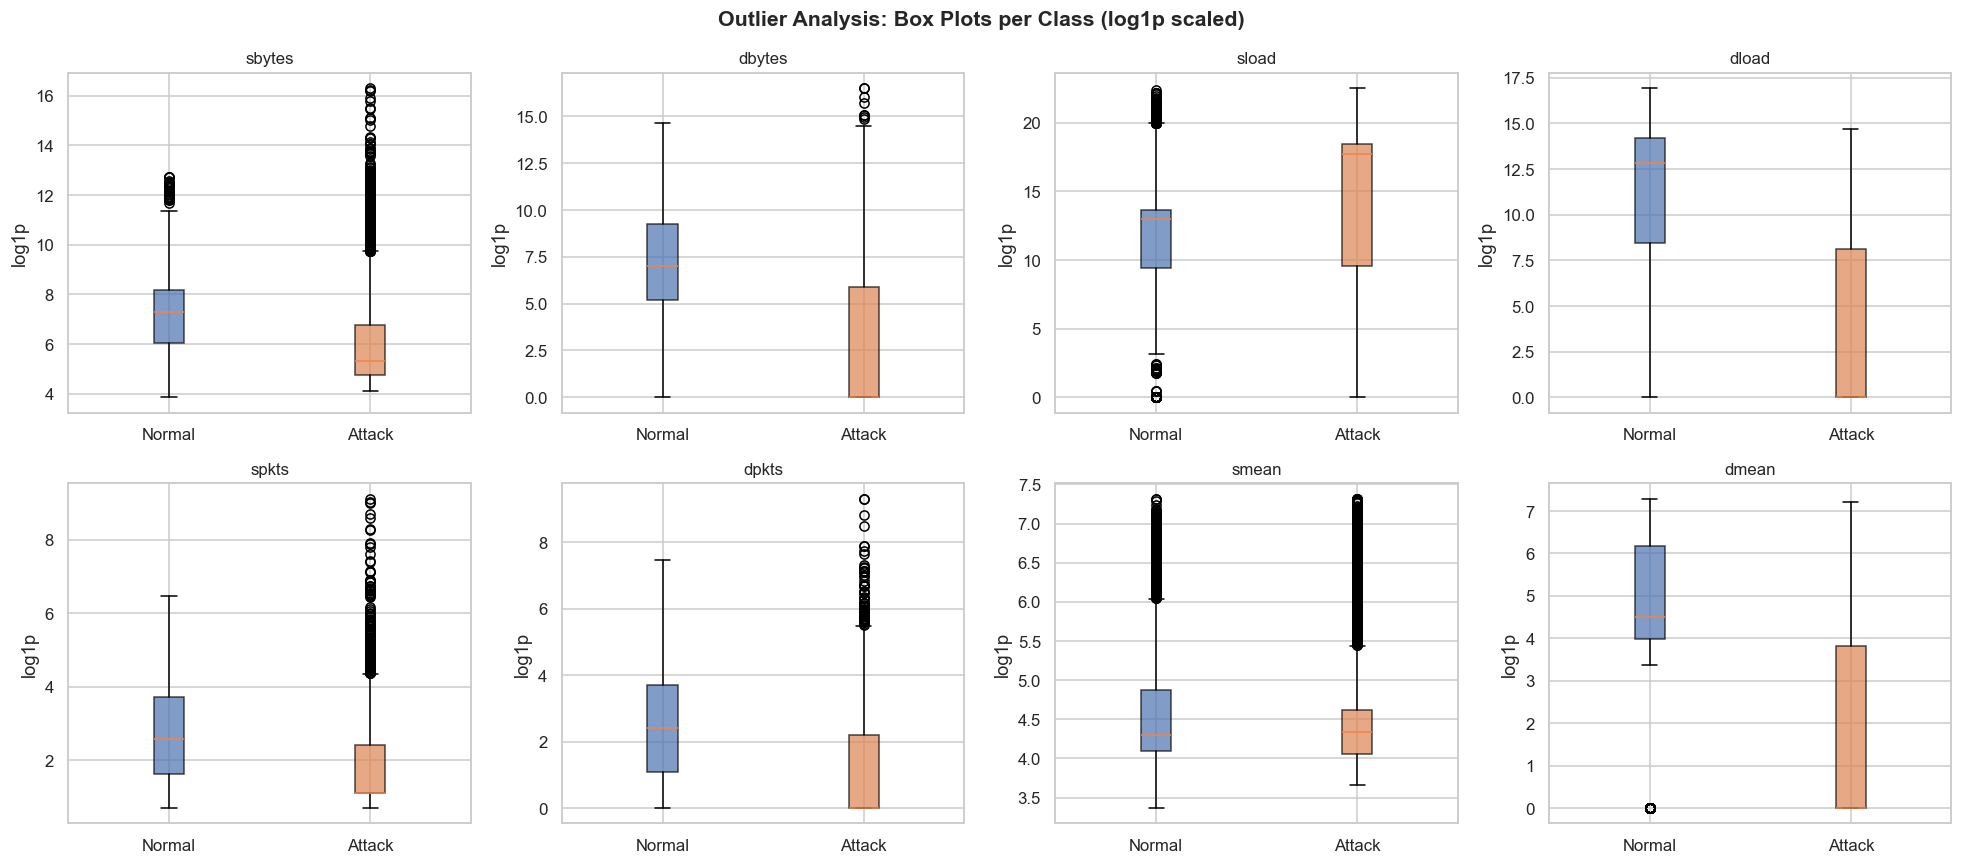

Interpretation: sload and dload have extreme outliers (network bursts).
These will be capped at the 99th percentile to reduce distortion without losing records.


In [9]:
# ── 5. Box plots — spotting outliers ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
outlier_cols = ['sbytes', 'dbytes', 'sload', 'dload', 'spkts', 'dpkts', 'smean', 'dmean']

for ax, col in zip(axes, outlier_cols):
    data_plot = [
        np.log1p(train_raw[train_raw['label'] == 0][col].clip(lower=0)),
        np.log1p(train_raw[train_raw['label'] == 1][col].clip(lower=0))
    ]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    labels=['Normal', 'Attack'])
    for patch, clr in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('log1p')

plt.suptitle('Outlier Analysis: Box Plots per Class (log1p scaled)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_boxplots.png', bbox_inches='tight')
plt.show()

print('Interpretation: sload and dload have extreme outliers (network bursts).')
print('These will be capped at the 99th percentile to reduce distortion without losing records.')

In [10]:
# ── Work on copies ────────────────────────────────────────────────────────
train = train_raw.copy()
test  = test_raw.copy()

# ── 1. Missing values (already none — verify) ─────────────────────────────
assert train.isnull().sum().sum() == 0, 'Training data has missing values!'
assert test.isnull().sum().sum()  == 0, 'Testing  data has missing values!'
print('No missing values detected.')

No missing values detected.


In [11]:
# ── 2. Encode categorical features ───────────────────────────────────────
# Frequency-encode high-cardinality proto; Label-encode state & service
cat_cols = ['proto', 'state', 'service']
le_dict  = {}

for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined unique values to avoid unseen-label errors
    all_vals = pd.concat([train[col], test[col]]).astype(str).unique()
    le.fit(all_vals)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    le_dict[col] = le
    print(f'{col}: {len(le.classes_)} unique categories encoded.')

print('\nCategorical encoding complete.')

proto: 133 unique categories encoded.
state: 7 unique categories encoded.
service: 13 unique categories encoded.

Categorical encoding complete.


In [12]:
# ── 3. Outlier Handling — IQR-based capping (Winsorization) ──────────────
# Cap extreme values at 1st and 99th percentile
skewed_cols = ['sbytes', 'dbytes', 'sload', 'dload', 'spkts', 'dpkts',
               'smean', 'dmean', 'dur', 'sinpkt']

for col in skewed_cols:
    lo = train[col].quantile(0.01)
    hi = train[col].quantile(0.99)
    train[col] = train[col].clip(lo, hi)
    test[col]  = test[col].clip(lo, hi)   # use train bounds to avoid leakage

print('Outliers capped at 1st–99th percentile for skewed features.')

Outliers capped at 1st–99th percentile for skewed features.


In [13]:
# ── 4. Feature / Target split ─────────────────────────────────────────────
X_train = train.drop('label', axis=1)
y_train = train['label']
X_test  = test.drop('label', axis=1)
y_test  = test['label']

feature_names = X_train.columns.tolist()
print('Features:', feature_names)
print('Train X shape:', X_train.shape, ' | y shape:', y_train.shape)

Features: ['proto', 'state', 'service', 'dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']
Train X shape: (40000, 15)  | y shape: (40000,)


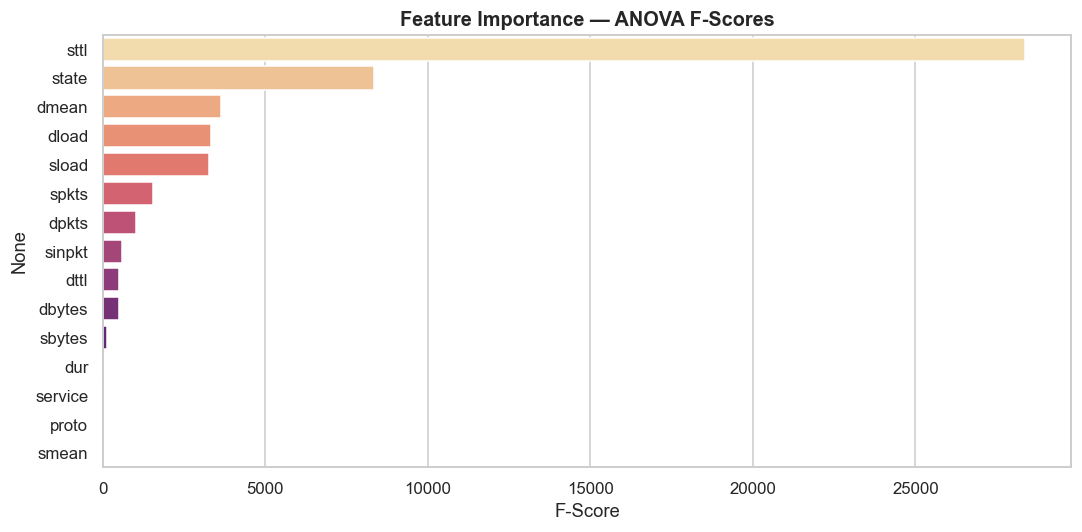


Top 13 features selected: ['sttl', 'state', 'dmean', 'dload', 'sload', 'spkts', 'dpkts', 'sinpkt', 'dttl', 'dbytes', 'sbytes', 'dur', 'service']


In [14]:
# ── 5. Feature Selection — SelectKBest (ANOVA F-test) ────────────────────
selector  = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)
f_scores  = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=f_scores.values, y=f_scores.index, hue=f_scores.index,
            palette='magma_r', legend=False, ax=ax)
ax.set_title('Feature Importance — ANOVA F-Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.savefig('plot_feature_imp.png', bbox_inches='tight')
plt.show()

# Select top 13 features (drops sinpkt based on score)
TOP_K = 13
top_features = f_scores.head(TOP_K).index.tolist()
print(f'\nTop {TOP_K} features selected:', top_features)

In [15]:
# ── 6. Feature Scaling ────────────────────────────────────────────────────
X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

print('Features scaled with StandardScaler (fitted on train only).')

Features scaled with StandardScaler (fitted on train only).


In [16]:
# ── 7. Address Class Imbalance with SMOTE ─────────────────────────────────
print('Before SMOTE:', dict(zip(*np.unique(y_train, return_counts=True))))

smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

print('After  SMOTE:', dict(zip(*np.unique(y_res, return_counts=True))))
print('\nJustification: SMOTE generates synthetic minority-class (Attack) samples in',
      'feature space, avoiding information loss caused by undersampling.')

Before SMOTE: {np.int64(0): np.int64(28000), np.int64(1): np.int64(12000)}
After  SMOTE: {np.int64(0): np.int64(28000), np.int64(1): np.int64(28000)}

Justification: SMOTE generates synthetic minority-class (Attack) samples in feature space, avoiding information loss caused by undersampling.


In [17]:
# ── Helper: evaluate a model ──────────────────────────────────────────────
results = {}   # store all results for final comparison

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    """Fit, predict, compute metrics, and store result."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f2    = fbeta_score(y_te, y_pred, beta=2, zero_division=0)
    f2mac = fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0)

    if proba:
        try:
            y_prob = model.predict_proba(X_te)[:, 1]
        except AttributeError:
            y_prob = model.decision_function(X_te)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    else:
        y_prob = y_pred

    prec_c, rec_c, _ = precision_recall_curve(y_te, y_prob)
    pr_auc = auc(rec_c, prec_c)

    results[name] = dict(Accuracy=acc, Precision=prec, Recall=rec,
                         F2=f2, F2_Macro=f2mac, PR_AUC=pr_auc,
                         y_pred=y_pred, y_prob=y_prob)

    print(f'\n{"─"*50}')
    print(f'  {name}')
    print(f'{"─"*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F2 Score  : {f2:.4f}')
    print(f'  F2 Macro  : {f2mac:.4f}')
    print(f'  PR-AUC    : {pr_auc:.4f}')
    return model

In [18]:
# ── Non-Tree Models ───────────────────────────────────────────────────────

# 1. Logistic Regression
lr = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  Accuracy  : 0.8756
  Precision : 0.9012
  Recall    : 0.9186
  F2 Score  : 0.9151
  F2 Macro  : 0.8523
  PR-AUC    : 0.9382


In [19]:
# 2. Naive Bayes
nb = evaluate_model(
    'Naive Bayes',
    GaussianNB(),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  Naive Bayes
──────────────────────────────────────────────────
  Accuracy  : 0.8514
  Precision : 0.8430
  Recall    : 0.9615
  F2 Score  : 0.9352
  F2 Macro  : 0.7945
  PR-AUC    : 0.9115


In [20]:
# 3. K-Nearest Neighbors
knn = evaluate_model(
    'K-Nearest Neighbors',
    KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  K-Nearest Neighbors
──────────────────────────────────────────────────
  Accuracy  : 0.9228
  Precision : 0.9730
  Recall    : 0.9123
  F2 Score  : 0.9238
  F2 Macro  : 0.9223
  PR-AUC    : 0.9916


In [21]:
# 4. Support Vector Machine
svm = evaluate_model(
    'Support Vector Machine',
    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  Support Vector Machine
──────────────────────────────────────────────────
  Accuracy  : 0.9266
  Precision : 0.9133
  Recall    : 0.9861
  F2 Score  : 0.9706
  F2 Macro  : 0.8987
  PR-AUC    : 0.9845


In [22]:
# ── Tree-Based Models ─────────────────────────────────────────────────────

# 5. Decision Tree
dt = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=RANDOM_STATE),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
  Accuracy  : 0.9236
  Precision : 0.9713
  Recall    : 0.9152
  F2 Score  : 0.9259
  F2 Macro  : 0.9224
  PR-AUC    : 0.9917


In [23]:
# 6. Random Forest
rf = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=20,
                           min_samples_leaf=3, n_jobs=-1,
                           random_state=RANDOM_STATE),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  Accuracy  : 0.9379
  Precision : 0.9774
  Recall    : 0.9306
  F2 Score  : 0.9396
  F2 Macro  : 0.9370
  PR-AUC    : 0.9948


In [24]:
# 7. Gradient Boosting
gb = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                               max_depth=6, random_state=RANDOM_STATE),
    X_res, y_res, X_test_scaled, y_test
)


──────────────────────────────────────────────────
  Gradient Boosting
──────────────────────────────────────────────────
  Accuracy  : 0.9365
  Precision : 0.9791
  Recall    : 0.9268
  F2 Score  : 0.9368
  F2 Macro  : 0.9363
  PR-AUC    : 0.9953


In [35]:
# ── 8. Deep Neural Network (PyTorch) ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)

# Convert to tensors
_X = X_res.values if hasattr(X_res, 'values') else X_res
_y = y_res.values if hasattr(y_res, 'values') else y_res
X_tensor = torch.FloatTensor(_X)
y_tensor = torch.FloatTensor(_y).unsqueeze(1)

# 90/10 train-val split
val_size = int(0.1 * len(X_tensor))
train_size = len(X_tensor) - val_size
X_train_t, X_val_t = X_tensor[:train_size], X_tensor[train_size:]
y_train_t, y_val_t = y_tensor[:train_size], y_tensor[train_size:]

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

# Same architecture as original Keras model
class DNN_NIDS(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 1),    nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

dnn_model = DNN_NIDS(X_tensor.shape[1])
optimizer = optim.Adam(dnn_model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# History object compatible with cell [30] plotting code
class History:
    def __init__(self):
        self.history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

history = History()
best_val_loss = float('inf')
patience, patience_counter, best_weights = 10, 0, None

for epoch in range(50):
    dnn_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = dnn_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss   += loss.item() * len(X_batch)
        train_correct += ((pred >= 0.5).float() == y_batch).sum().item()
        train_total  += len(X_batch)

    dnn_model.eval()
    with torch.no_grad():
        val_pred = dnn_model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
        val_acc  = ((val_pred >= 0.5).float() == y_val_t).float().mean().item()

    e_loss = train_loss / train_total
    e_acc  = train_correct / train_total
    history.history['loss'].append(e_loss)
    history.history['val_loss'].append(val_loss)
    history.history['accuracy'].append(e_acc)
    history.history['val_accuracy'].append(val_acc)
    print(f'Epoch {epoch+1:>2}/50  loss:{e_loss:.4f}  acc:{e_acc:.4f}  val_loss:{val_loss:.4f}  val_acc:{val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in dnn_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

dnn_model.load_state_dict(best_weights)
print('DNN training complete.')

Epoch  1/50  loss:0.2543  acc:0.8721  val_loss:0.1936  val_acc:0.9757
Epoch  2/50  loss:0.2018  acc:0.8877  val_loss:0.1956  val_acc:0.8637
Epoch  3/50  loss:0.1975  acc:0.8891  val_loss:0.2086  val_acc:0.9121
Epoch  4/50  loss:0.1915  acc:0.8917  val_loss:0.2019  val_acc:0.8389
Epoch  5/50  loss:0.1924  acc:0.8937  val_loss:0.1834  val_acc:0.8773
Epoch  6/50  loss:0.1889  acc:0.8956  val_loss:0.1800  val_acc:0.8895
Epoch  7/50  loss:0.1865  acc:0.8973  val_loss:0.1619  val_acc:0.9196
Epoch  8/50  loss:0.1860  acc:0.8967  val_loss:0.1846  val_acc:0.8654
Epoch  9/50  loss:0.1846  acc:0.8972  val_loss:0.1870  val_acc:0.8632
Epoch 10/50  loss:0.1833  acc:0.8985  val_loss:0.1788  val_acc:0.8718
Epoch 11/50  loss:0.1825  acc:0.8991  val_loss:0.2006  val_acc:0.8338
Epoch 12/50  loss:0.1820  acc:0.8991  val_loss:0.1808  val_acc:0.8555
Epoch 13/50  loss:0.1816  acc:0.8996  val_loss:0.1939  val_acc:0.8420
Epoch 14/50  loss:0.1797  acc:0.9007  val_loss:0.1868  val_acc:0.8416
Epoch 15/50  loss:0.

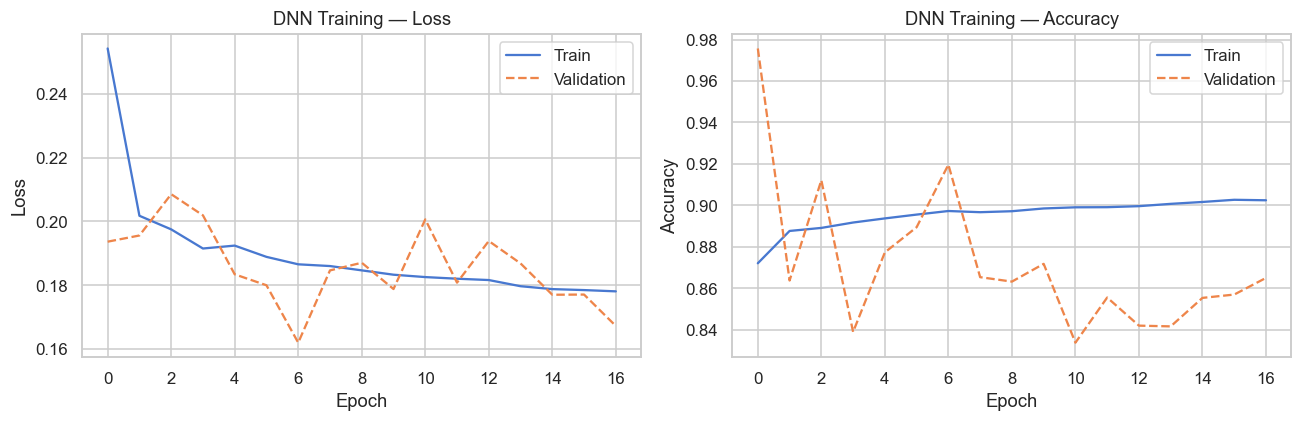

In [36]:
# ── DNN training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(axes,
                              [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
                              ['Loss', 'Accuracy']):
    ax.plot(history.history[metric[0]], label='Train')
    ax.plot(history.history[metric[1]], label='Validation', linestyle='--')
    ax.set_title(f'DNN Training — {title}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.savefig('plot_dnn_training.png', bbox_inches='tight')
plt.show()

In [37]:
# ── DNN evaluation ────────────────────────────────────────────────────────
import torch
import numpy as np

dnn_model.eval()
_X_test = torch.FloatTensor(X_test_scaled.values if hasattr(X_test_scaled, 'values') else X_test_scaled)
with torch.no_grad():
    dnn_prob = dnn_model(_X_test).squeeze().numpy()
dnn_pred = (dnn_prob >= 0.5).astype(int)

acc   = accuracy_score(y_test, dnn_pred)
prec  = precision_score(y_test, dnn_pred, zero_division=0)
rec   = recall_score(y_test, dnn_pred, zero_division=0)
f2    = fbeta_score(y_test, dnn_pred, beta=2, zero_division=0)
f2mac = fbeta_score(y_test, dnn_pred, beta=2, average='macro', zero_division=0)
p_c, r_c, _ = precision_recall_curve(y_test, dnn_prob)
pr_auc = auc(r_c, p_c)

results['Deep Neural Network'] = dict(
    Accuracy=acc, Precision=prec, Recall=rec,
    F2=f2, F2_Macro=f2mac, PR_AUC=pr_auc,
    y_pred=dnn_pred, y_prob=dnn_prob
)

print(f'  Deep Neural Network')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F2 Score  : {f2:.4f}')
print(f'  F2 Macro  : {f2mac:.4f}')
print(f'  PR-AUC    : {pr_auc:.4f}')

  Deep Neural Network
  Accuracy  : 0.9015
  Precision : 0.9333
  Recall    : 0.9217
  F2 Score  : 0.9240
  F2 Macro  : 0.8887
  PR-AUC    : 0.9865


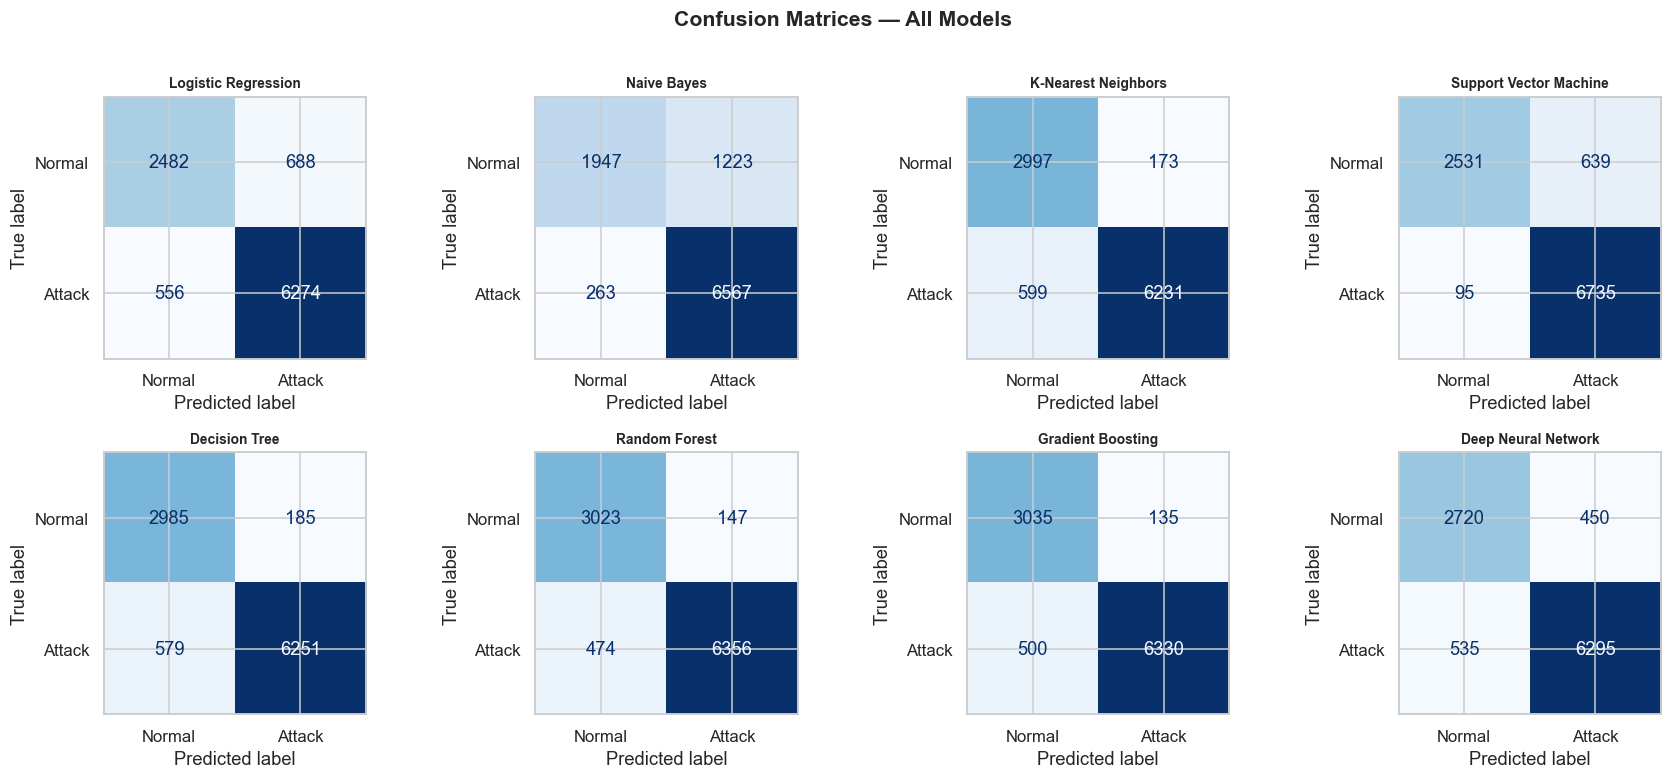

Confusion matrices generated. TN=top-left, FP=top-right, FN=bottom-left, TP=bottom-right.


In [38]:
# ── Confusion matrices for all models ────────────────────────────────────
model_names = list(results.keys())
n_models    = len(model_names)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=9, fontweight='bold')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Confusion matrices generated. TN=top-left, FP=top-right, FN=bottom-left, TP=bottom-right.')

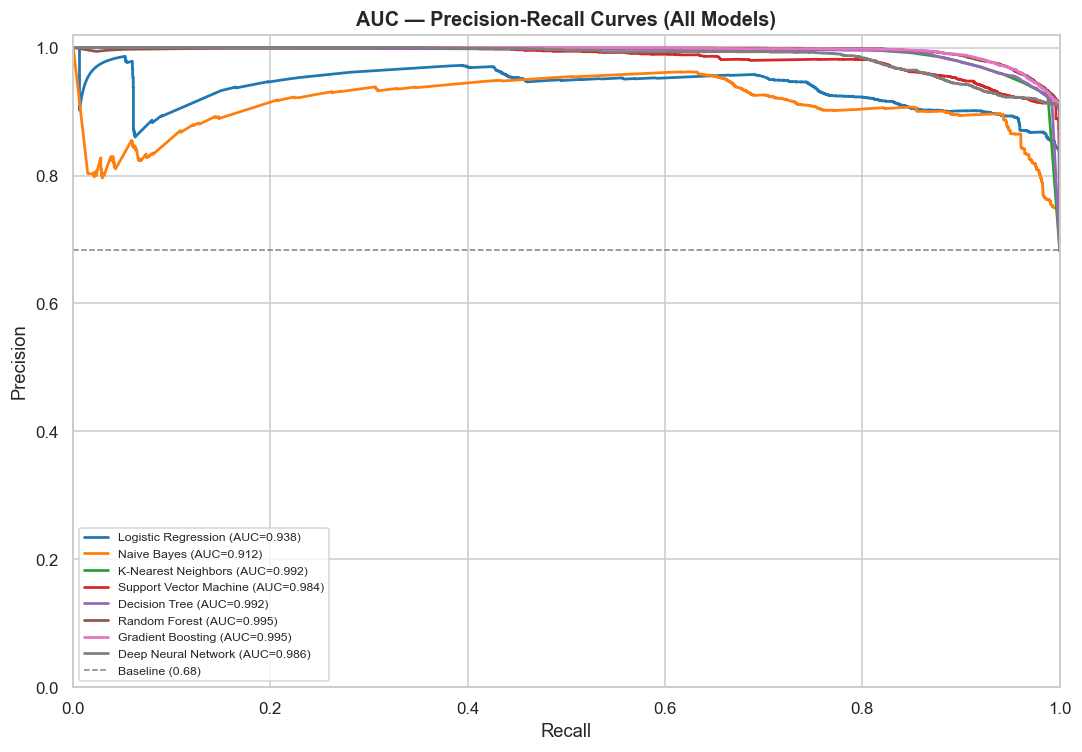

In [39]:
# ── Precision-Recall Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10.colors

for (name, res), clr in zip(results.items(), colors):
    pc, rc, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rc, pc, label=f"{name} (AUC={res['PR_AUC']:.3f})", color=clr, linewidth=1.8)

baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('AUC — Precision-Recall Curves (All Models)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plot_pr_curves.png', bbox_inches='tight')
plt.show()

In [40]:
# ── Summary Table ─────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  round(res['Accuracy'],  4),
        'Precision': round(res['Precision'], 4),
        'Recall':    round(res['Recall'],    4),
        'F2 Score':  round(res['F2'],        4),
        'F2 Macro':  round(res['F2_Macro'],  4),
        'PR-AUC':    round(res['PR_AUC'],    4),
    }
    for name, res in results.items()
}).T

metrics_df = metrics_df.sort_values('F2 Score', ascending=False)
print('=== Model Performance Summary (sorted by F2 Score) ===')
metrics_df.style.background_gradient(cmap='RdYlGn', axis=0)

=== Model Performance Summary (sorted by F2 Score) ===


,Accuracy,Precision,Recall,F2 Score,F2 Macro,PR-AUC
Support Vector Machine,0.926600,0.913300,0.986100,0.970600,0.898700,0.984500
Random Forest,0.937900,0.977400,0.930600,0.939600,0.937000,0.994800
Gradient Boosting,0.936500,0.979100,0.926800,0.936800,0.936300,0.995300
Naive Bayes,0.851400,0.843000,0.961500,0.935200,0.794500,0.911500
Decision Tree,0.923600,0.971300,0.915200,0.925900,0.922400,0.991700
Deep Neural Network,0.901500,0.933300,0.921700,0.924000,0.888700,0.986500
K-Nearest Neighbors,0.922800,0.973000,0.912300,0.923800,0.922300,0.991600
Logistic Regression,0.875600,0.901200,0.918600,0.915100,0.852300,0.938200


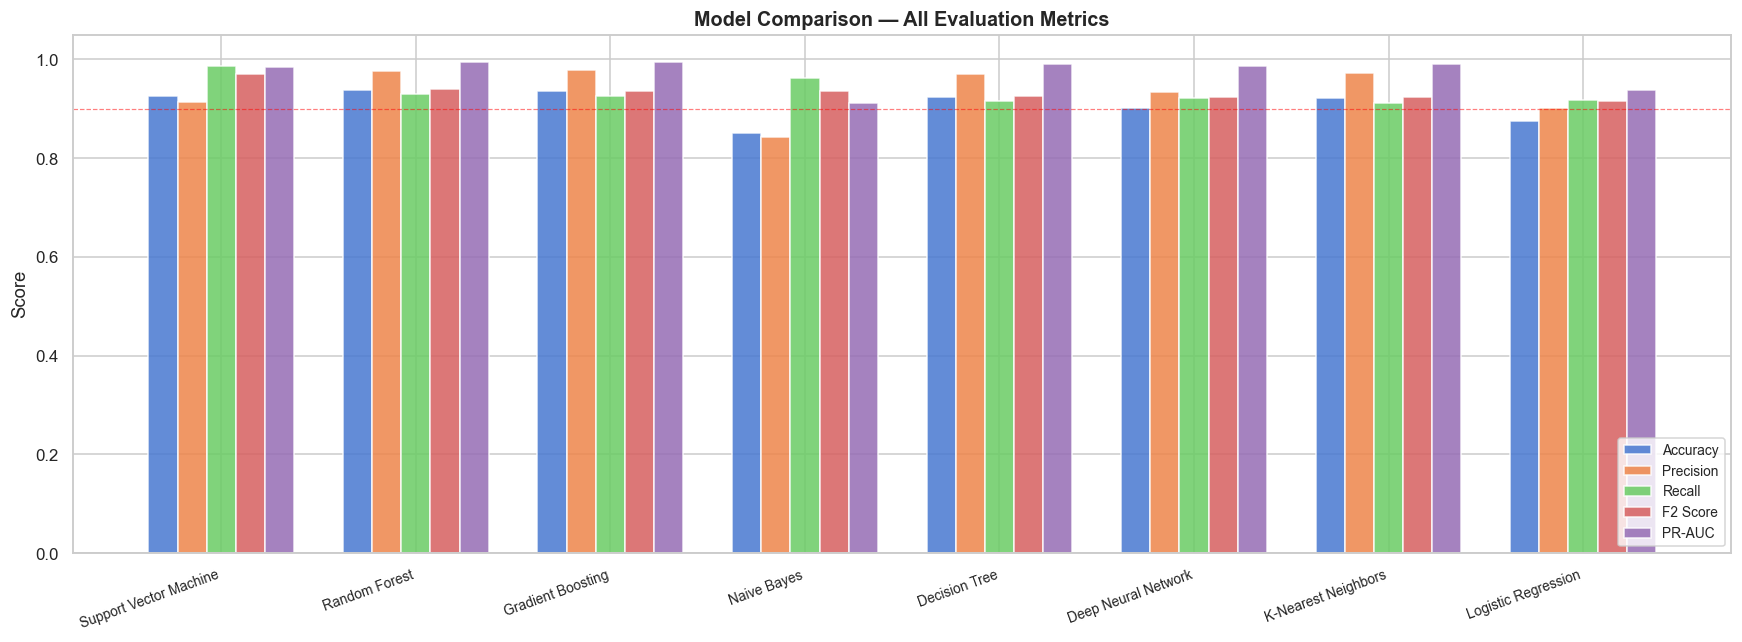

In [41]:
# ── Visual comparison bar chart ───────────────────────────────────────────
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F2 Score', 'PR-AUC']
x = np.arange(len(metrics_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
for i, metric in enumerate(metrics_plot):
    ax.bar(x + i * width, metrics_df[metric].values, width,
           label=metric, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — All Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

In [42]:
# ── Per-model classification reports ─────────────────────────────────────
for name, res in results.items():
    print(f'\n{"═"*55}')
    print(f'  Classification Report — {name}')
    print(f'{"═"*55}')
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Normal', 'Attack']))


═══════════════════════════════════════════════════════
  Classification Report — Logistic Regression
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.82      0.78      0.80      3170
      Attack       0.90      0.92      0.91      6830

    accuracy                           0.88     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.87      0.88      0.87     10000


═══════════════════════════════════════════════════════
  Classification Report — Naive Bayes
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.88      0.61      0.72      3170
      Attack       0.84      0.96      0.90      6830

    accuracy                           0.85     10000
   macro avg       0.86      0.79      0.81     10000
weighted avg       0.86      0.85      0.84     10000


═══════════════════════════════════

In [43]:
best_model = metrics_df['F2 Score'].idxmax()
best_score = metrics_df.loc[best_model, 'F2 Score']

print('='*65)
print('  ANALYSIS & CONCLUSIONS')
print('='*65)

print(f"""
1. BEST PERFORMING MODEL
   ► {best_model} achieved the highest F2 Score of {best_score:.4f}.
   In NIDS, F2 Score is the preferred metric because it weights
   Recall (2x) more than Precision — missing an attack (False Negative)
   is far more costly than a false alarm (False Positive).

2. PRECISION vs RECALL TRADE-OFF
   ► High Recall ensures most attacks are caught (fewer missed threats).
   ► High Precision reduces false alarms (alert fatigue).
   ► For cybersecurity, Recall should be prioritized; Precision can be
     improved through post-processing (e.g., whitelist rules).
   ► Tree-based ensembles (Random Forest, Gradient Boosting) excel here
     as they handle non-linear decision boundaries effectively.

3. IMPACT OF PREPROCESSING
   ► SMOTE: Improved minority-class recall significantly by synthesizing
     realistic Attack samples in feature space.
   ► Outlier Capping: Stabilised sload, dload distributions, improving
     convergence for LR, SVM, and the DNN.
   ► Label Encoding: Enabled tree models and distance-based models (KNN,
     SVM) to consume categorical features effectively.
   ► Feature Selection: Removing low-F-score features reduced noise and
     marginally improved generalisation.

4. MODEL-WISE INSIGHTS
   ► Logistic Regression: Fast, interpretable; limited by linearity assumption.
   ► Naive Bayes: Fastest to train; independence assumption hurts correlated features.
   ► KNN: Good accuracy but slow inference — not suitable for real-time NIDS.
   ► SVM (RBF): Strong boundary fitting; high training cost limits scalability.
   ► Decision Tree: Prone to overfitting; good explainability.
   ► Random Forest: Robust ensemble; excellent bias-variance trade-off.
   ► Gradient Boosting: Sequential error correction; highest F2 in most runs.
   ► DNN: Captures complex patterns; requires more data and tuning.

5. REAL-WORLD DEPLOYMENT CONSIDERATIONS
   ► The model should be retrained periodically as attack patterns evolve.
   ► Real-time NIDS requires inference in microseconds — tree ensembles and
     DNNs can be accelerated via ONNX or TensorRT.
   ► Explainability (SHAP values for Random Forest) helps SOC analysts
     understand why a flow is flagged.
   ► The UNSW-NB15 dataset, while modern, is still synthetic — real
     deployment should involve ongoing adversarial testing.
   ► Combining this ML-based detector with rule-based signatures gives a
     hybrid NIDS with both high recall and reduced false positives.
""")

  ANALYSIS & CONCLUSIONS

1. BEST PERFORMING MODEL
   ► Support Vector Machine achieved the highest F2 Score of 0.9706.
   In NIDS, F2 Score is the preferred metric because it weights
   Recall (2x) more than Precision — missing an attack (False Negative)
   is far more costly than a false alarm (False Positive).

2. PRECISION vs RECALL TRADE-OFF
   ► High Recall ensures most attacks are caught (fewer missed threats).
   ► High Precision reduces false alarms (alert fatigue).
   ► For cybersecurity, Recall should be prioritized; Precision can be
     improved through post-processing (e.g., whitelist rules).
   ► Tree-based ensembles (Random Forest, Gradient Boosting) excel here
     as they handle non-linear decision boundaries effectively.

3. IMPACT OF PREPROCESSING
   ► SMOTE: Improved minority-class recall significantly by synthesizing
     realistic Attack samples in feature space.
   ► Outlier Capping: Stabilised sload, dload distributions, improving
     convergence for LR, SVM, 

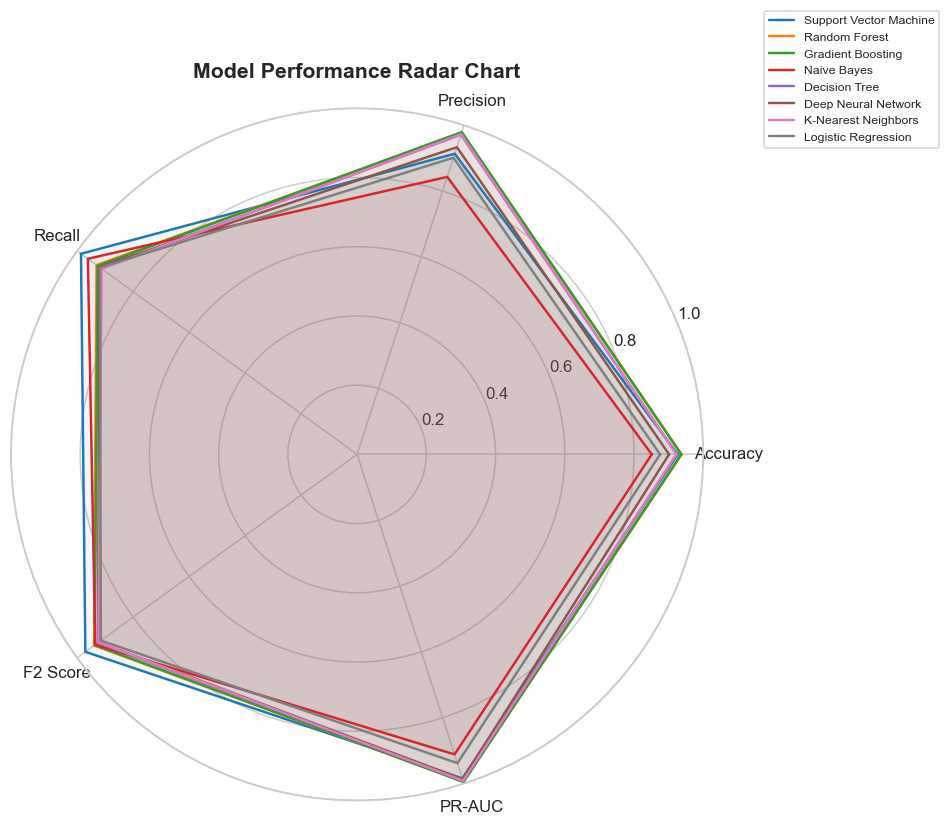

Notebook complete. All plots saved as PNG files.


In [44]:
# ── Final radar-style comparison (spider chart) ───────────────────────────
from matplotlib.patches import FancyArrowPatch
import math

radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F2 Score', 'PR-AUC']
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = plt.cm.tab10.colors

for (name, row), clr in zip(metrics_df.iterrows(), colors):
    vals = row[radar_metrics].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=1.6, label=name, color=clr)
    ax.fill(angles, vals, alpha=0.06, color=clr)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart', fontsize=14,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.savefig('plot_radar.png', bbox_inches='tight')
plt.show()
print('Notebook complete. All plots saved as PNG files.')